In [4]:
import numpy as np
from field_decay.constants import M_suncgs
from field_decay.compact_object import NS
from field_decay.accretion import mass_transfer_rate_mag_radius_secant, spherization_radius_poutanen, mass_transfer_inner_radius, magnetic_moment
import matplotlib.pyplot as plt

## Figure 3

(1, 7943.282347242814)

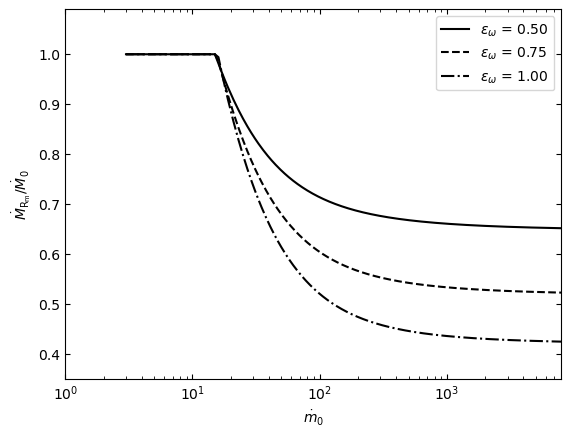

In [2]:
B = 10**12 
ns = NS(10, B=B)
mdots = np.arange(3, 10000)
Mdots = ns.MEdd * mdots
mu = ns.mu
lss  = ["solid", "--", "-.", "dotted"]
e_winds = [0.5, 0.75 , 1]
fig = plt.figure()
for j, e_wind in enumerate(e_winds):
    mdotsin = []
    for Mdot in Mdots:
        Rsph = spherization_radius_poutanen(Mdot /ns.MEdd, ns.Risco, e_wind)
        mass_transfered = mass_transfer_rate_mag_radius_secant(Mdot, mu, ns.MEdd, Rsph, ns.M, 
                                                                  e_wind=e_wind, tol=1e-4, max_iter=100000)
        mdotsin.append(mass_transfered)
    plt.plot(mdots, mdotsin / (Mdots), 
             label=r"$\epsilon_\omega$ = %.2f" % e_wind, 
             ls=lss[j], color="black")

plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.gca().tick_params(direction="in", which="both")
plt.xlabel(r"$\dot{m}_\mathrm{0}$")
plt.ylabel(r"$\dot{M}_\mathrm{R_m}/\dot{M}_\mathrm{0}$")
plt.xscale("log")
plt.legend()
plt.ylim(0.35, 1.09)
plt.xlim(1, 10**3.9)
#plt.savefig("mushtukov_2019_figure3.png")
#plt.close(fig)


## Figure 2

Small differences could be due to numerical factors (e.g. Rsph, magnetic moment, etc)


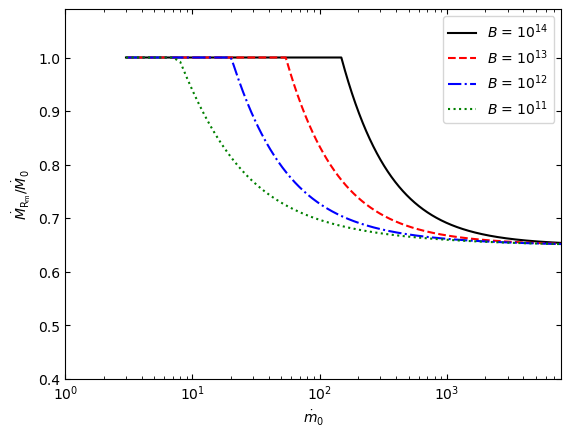

In [5]:
colors = ["black", "red", "blue", "green"]
e_wind = 0.5
Bs = np.flip(np.geomspace(10**11, 10**14, 4))
plt.figure()
for j, B in enumerate(Bs):
    mdotsin = []
    mu = magnetic_moment(B, ns.R_NS) * 2.
    for Mdot in Mdots:
        Rsph = spherization_radius_poutanen(Mdot /ns.MEdd, ns.Risco, e_wind)
        mass_transfered = mass_transfer_rate_mag_radius_secant(Mdot, mu, ns.MEdd, Rsph, ns.M, 
                                                               e_wind=e_wind, tol=1e-20)
        mdotsin.append(mass_transfered)
    plt.plot(mdots, mdotsin / (Mdots), label=r"$B$ = 10$^{%d}$" % (np.log10(B)), 
             ls=lss[j], color=colors[j])

plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.gca().tick_params(direction="in", which="both")
plt.ylim(0.4, 1.09)
plt.xlim(1, 10**3.9)
plt.xlabel(r"$\dot{m}_\mathrm{0}$")
plt.ylabel(r"$\dot{M}_\mathrm{R_m}/\dot{M}_\mathrm{0}$")
plt.xscale("log")
plt.legend()
print("Small differences could be due to numerical factors (e.g. Rsph, magnetic moment, etc)")
#plt.savefig("mushtukov_2019_figure2.png")